# Неделя 6. Модель Theta и её вариации

Theta — простой метод, который выиграл соревнование M3 и до сих пор служит бейзлайном.
В statsforecast пять моделей семейства:

| Класс | Короткое имя | θ | Тренд $A_n + B_n t$ |
|---|---|---|---|
| `Theta` | STM | 2 | одна МНК-прямая по всему ряду |
| `OptimizedTheta` | OTM | обучается | одна МНК-прямая |
| `DynamicTheta` | DSTM | 2 | пересчитывается на каждом шаге |
| `DynamicOptimizedTheta` | DOTM | обучается | пересчитывается на каждом шаге |
| `AutoTheta` | — | — | выбирает одну из четырёх |

Для каждой модели: идея и обучаемые параметры → гиперпараметры → прогноз.
В конце — сравнение с ETS и ARIMA на рядах M4.

In [1]:
import time
import warnings
from functools import partial

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from statsforecast import StatsForecast
from statsforecast.models import (
    AutoARIMA,
    AutoETS,
    AutoTheta,
    DynamicOptimizedTheta,
    DynamicTheta,
    OptimizedTheta,
    SeasonalNaive,
    Theta,
)
from statsmodels.tsa.forecasting.theta import ThetaModel
from statsmodels.tsa.seasonal import seasonal_decompose
from utilsforecast.evaluation import evaluate
from utilsforecast.losses import mase, smape
from utilsforecast.plotting import plot_series

warnings.simplefilter("ignore")
plt.rcParams["figure.figsize"] = (12, 4)
plt.rcParams["axes.grid"] = True
pd.set_option("display.precision", 3)

## Данные

- **AirPassengers** — месячный ряд с трендом и мультипликативной сезонностью;
  последние 24 месяца — тест.
- **Синтетика** — линейный тренд с изломом (наклон 0.2 → 1.0 после $t=80$) и шум, без сезонности.
- **M4 Monthly** — 50 случайных месячных рядов соревнования M4 (последние ≤ 240 точек),
  `ds` — номер месяца

In [3]:
air = pd.read_csv("../data/air_passengers.csv", parse_dates=["Month"])
air = air.rename(columns={"Month": "ds", "#Passengers": "y"}).assign(unique_id="air")[["unique_id", "ds", "y"]]
H_AIR = 24
air_train, air_test = air.iloc[:-H_AIR], air.iloc[-H_AIR:]

rng = np.random.default_rng(1)
t = np.arange(144)
syn_y = 100 + 0.2 * t + 0.8 * np.maximum(t - 80, 0) + rng.normal(0, 2, len(t))
syn = pd.DataFrame({"unique_id": "syn", "ds": t + 1, "y": syn_y})
H_SYN = 24
syn_train, syn_test = syn.iloc[:-H_SYN], syn.iloc[-H_SYN:]

m4 = pd.read_csv("../data/m4_monthly_sample.csv")
m4.groupby("unique_id").size().describe()[["count", "min", "50%", "max"]]

count     50.0
min      138.0
50%      240.0
max      240.0
dtype: float64

Один хелпер: обучить `StatsForecast` и достать словарь обученной модели `model_`
(параметры, состояния, сезонность) для ряда `i` и модели `j`.

In [4]:
def fitted_model(sf, i=0, j=0):
    return sf.fitted_[i, j].model_

## 1. Идея: θ-линии

Возьмём несезонный ряд $y_t$ и МНК-прямую $A_n + B_n t$ по всем $n$ точкам.
**θ-линия** растягивает отклонения ряда от прямой в θ раз:

$$Z_t(\theta) = \theta\, y_t + (1-\theta)(A_n + B_n t).$$

- $\theta = 0$ — сама прямая (долгосрочный тренд);
- $\theta = 1$ — исходный ряд;
- $\theta = 2$ — «изгибы» удвоены (краткосрочная динамика).

Нарисуем линии на AirPassengers без сезонности (классическая мультипликативная декомпозиция —
ниже увидим, что statsforecast делает так же).

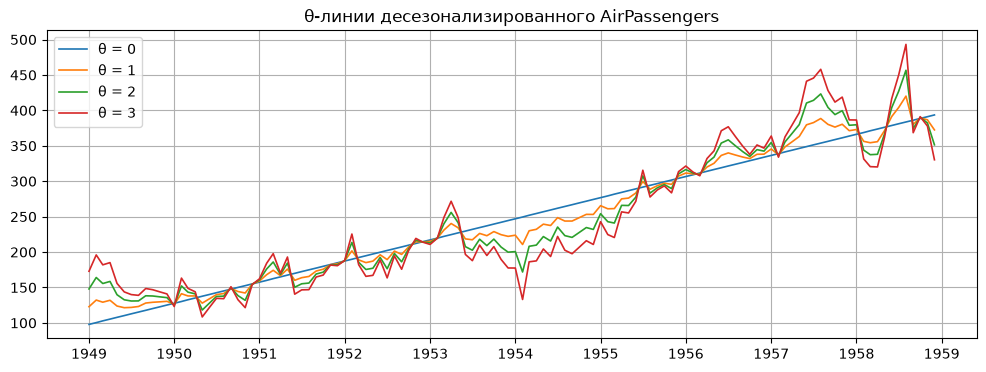

In [5]:
y_sa = air_train["y"].values / seasonal_decompose(air_train["y"].values, model="multiplicative", period=12).seasonal
tt = np.arange(1, len(y_sa) + 1)
B, A = np.polyfit(tt, y_sa, 1)

fig, ax = plt.subplots()
for theta in [0, 1, 2, 3]:
    ax.plot(air_train["ds"], theta * y_sa + (1 - theta) * (A + B * tt), label=f"θ = {theta}", lw=1.2)
ax.legend()
ax.set_title("θ-линии десезонализированного AirPassengers");

**Классический метод** (Assimakopoulos & Nikolopoulos, 2000): прямую $Z(0)$ продолжаем
линейно, $Z(2)$ — простым экспоненциальным сглаживанием (SES), прогноз — среднее двух.
Hyndman & Billah (2003) показали, что это SES с дрейфом $B_n/2$.

В общем виде θ задаёт вес между трендом и SES:

$$\hat y_{n+h} = \Big(1 - \tfrac{1}{\theta}\Big)\big(A_n + B_n (n+h)\big) + \tfrac{1}{\theta}\,\tilde Z_{n+h}(\theta).$$

Обе части видно в statsmodels: `forecast_components` возвращает тренд, прогноз SES и сезонность.

In [6]:
air_s = air_train.set_index("ds")["y"].asfreq("MS")
sm_res = ThetaModel(air_s, period=12).fit()
print(sm_res.params)
sm_res.forecast_components(H_AIR).head()

b0       2.485
alpha    0.934
dtype: float64


,trend,ses,seasonal
1959-01-01,2.660,373.43,0.912
1959-02-01,5.145,373.43,0.892
1959-03-01,7.630,373.43,1.022
1959-04-01,10.115,373.43,0.978
1959-05-01,12.600,373.43,0.977


- `ses` — горизонтальная линия (прогноз SES);
- `trend` растёт на $\hat b_0 \approx 2.49$ в месяц — это наклон МНК-прямой $B_n$;
- `seasonal` — сезонные индексы.

Прогноз: $\big((1-\tfrac1\theta)\cdot\text{trend} + \text{ses}\big)\cdot\text{seasonal}$.
При θ = 2 наклон прогноза вдвое меньше наклона прямой — так Theta «гасит» тренд.

## 2. Как устроено в statsforecast

Все пять классов — это `AutoTheta` с фиксированным `model`. Шаги `fit`:

1. **Тест на сезонность** (если `season_length ≥ 4` и в ряде не меньше двух сезонов):
   автокорреляция на лаге $m$ сравнивается с порогом 90%.
2. **Десезонализация** классической `seasonal_decompose` (не STL). По умолчанию
   `decomposition_type="multiplicative"`; переход на аддитивную, если в ряде есть $y \le 0$
   или сезонные индексы < 0.01. Прогноз сезонности — повтор последнего цикла.
3. **Модель на ряде без сезонности.** Nelder–Mead минимизирует сумму квадратов ошибок
   прогноза на шаг вперёд (без первых трёх точек, делённую на $\overline{|y|}$).

Обучаемые параметры:

| Параметр | Смысл | Границы | Модели |
|---|---|---|---|
| $\ell_0$ | начальный уровень SES | — | все |
| $\alpha$ | сглаживание SES | [0.1, 0.99] | все |
| $\theta$ | вес тренда | [1, ∞) | OTM, DOTM |

Гиперпараметры классов: `season_length`, `decomposition_type`, `prediction_intervals`
(конформные интервалы вместо встроенных), `alias`. У `AutoTheta` ещё `model` и `distribution`.
Задать $\alpha$ или θ руками через классы нельзя.

Всё, что выучила модель, лежит в `model_`:

In [7]:
sf = StatsForecast(models=[Theta(season_length=12)], freq="MS").fit(air_train)
md = fitted_model(sf)
{k: md[k] for k in ["modeltype", "par", "decompose", "decomposition_type", "mse"]}

{'modeltype': 'STM',
 'par': {'initial_smoothed': np.float64(9.406972717004777),
  'alpha': np.float64(0.8796875000000008),
  'theta': 2.0},
 'decompose': np.True_,
 'decomposition_type': 'multiplicative',
 'mse': 34.949604726677585}

`seas_forecast` — 12 сезонных индексов, которыми умножается прогноз.
Совпадают с индексами `seasonal_decompose` за последний год train.

In [8]:
seas = seasonal_decompose(air_train["y"].values, model="multiplicative", period=12).seasonal[-12:]
np.allclose(md["seas_forecast"]["mean"], seas)

True

## 3. Theta (STM)

θ = 2 фиксирован, обучаются $\ell_0$ и $\alpha$. Это стандартный метод Theta
в форме модели пространства состояний (Fiorucci et al., 2016).

**Гиперпараметры:**
- `season_length=1` — сезонность не убирается, прогноз — прямая;
- `decomposition_type="additive"` — амплитуда сезонности не растёт с уровнем.

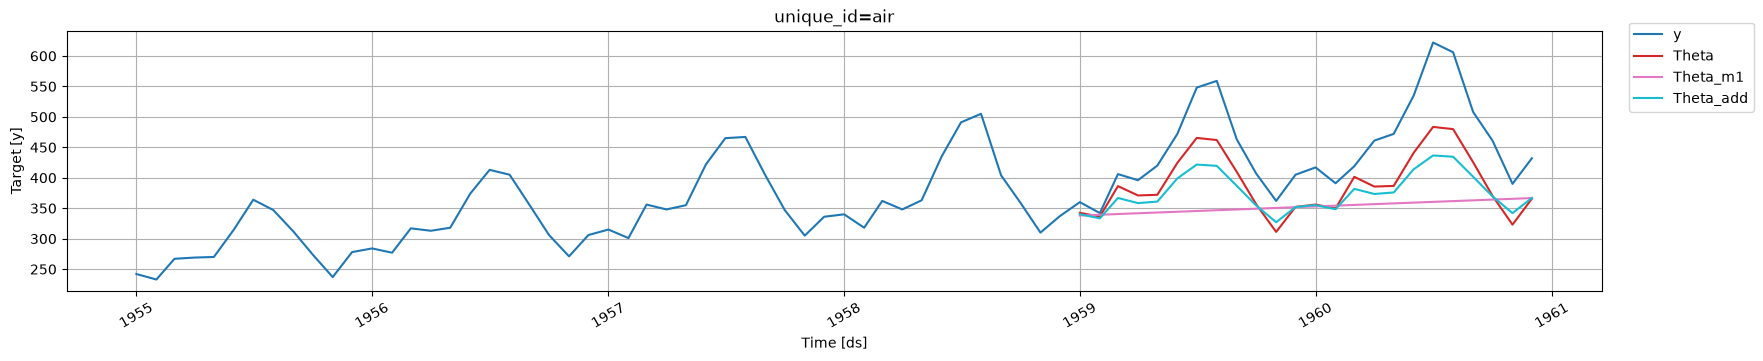

In [9]:
air_models = [
    Theta(season_length=12),
    Theta(season_length=1, alias="Theta_m1"),
    Theta(season_length=12, decomposition_type="additive", alias="Theta_add"),
]
sf = StatsForecast(models=air_models, freq="MS")
fc = sf.forecast(df=air_train, h=H_AIR, level=[80, 95])

fig = plot_series(air.iloc[-72:], fc, models=["Theta", "Theta_m1", "Theta_add"])
fig

In [10]:
evaluate(air_test.merge(fc, on=["unique_id", "ds"]), metrics=[smape],
         models=["Theta", "Theta_m1", "Theta_add"])

,unique_id,metric,Theta,Theta_m1,Theta_add
0,air,smape,0.071,0.117,0.087


Мультипликативная десезонализация лучше: у AirPassengers сезонные колебания растут с уровнем.
Интервалы — по выборкам из модели пространства состояний:

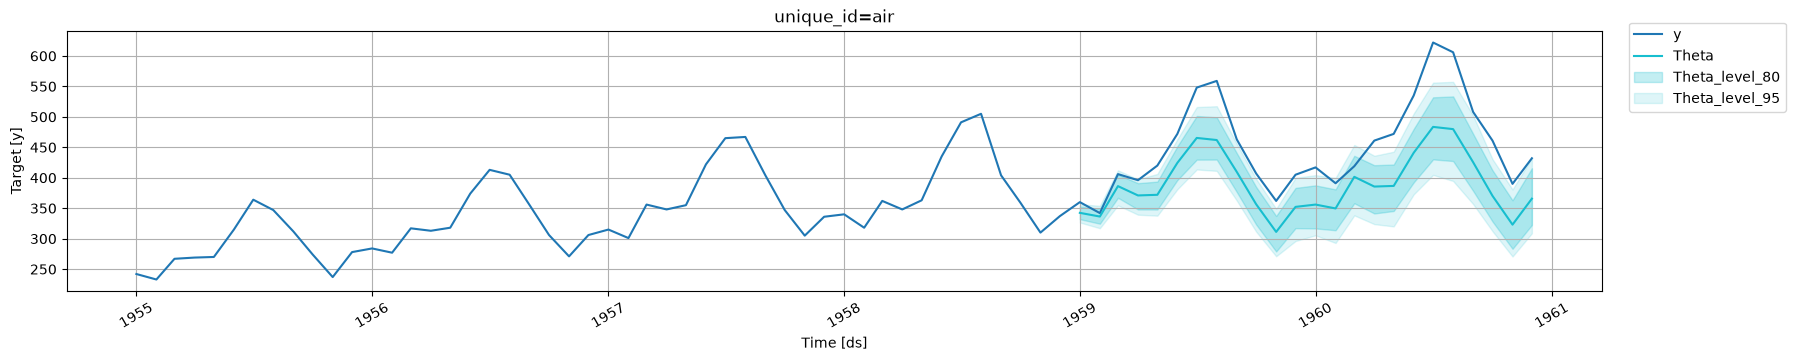

In [11]:
plot_series(air.iloc[-72:], fc, models=["Theta"], level=[80, 95])

Тот же метод есть в statsmodels (`ThetaModel`, θ = 2 по умолчанию). Прогнозы почти совпадают,
отличия — в способе оценки $\alpha$:

In [12]:
np.abs(sm_res.forecast(H_AIR).values - fc["Theta"].values).max()

np.float64(1.0660803263414778)

## 4. OptimizedTheta (OTM)

θ обучается вместе с $\ell_0$ и $\alpha$:
- θ = 1 — чистый SES, тренда нет;
- θ → ∞ — SES с полным дрейфом $B_n$.

Как θ меняет прогноз, видно в statsmodels: там θ можно передать в `forecast`.

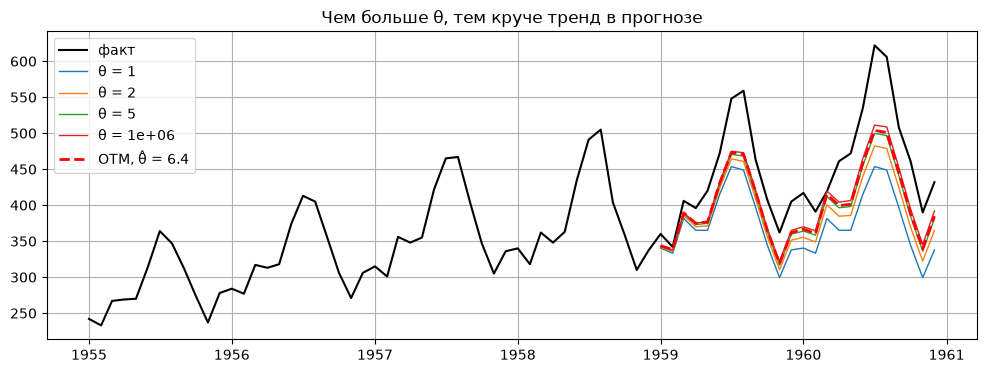

In [13]:
sf = StatsForecast(models=[OptimizedTheta(season_length=12)], freq="MS").fit(air_train)
theta_otm = fitted_model(sf)["par"]["theta"]
fc_otm = sf.predict(h=H_AIR)

fig, ax = plt.subplots()
ax.plot(air["ds"].iloc[-72:], air["y"].iloc[-72:], color="black", lw=1.5, label="факт")
for theta in [1, 2, 5, 1e6]:
    ax.plot(air_test["ds"], sm_res.forecast(H_AIR, theta=theta), lw=1, label=f"θ = {theta:g}")
ax.plot(air_test["ds"], fc_otm["OptimizedTheta"], color="red", ls="--", lw=2, label=f"OTM, θ̂ = {theta_otm:.1f}")
ax.legend()
ax.set_title("Чем больше θ, тем круче тренд в прогнозе");

На AirPassengers тренд сильный, и OTM выбирает θ ≈ 6: прогноз круче, чем у STM.

На синтетике с изломом свобода по θ тоже помогает: МНК-прямая по всему ряду
усредняет оба наклона, и большой θ даёт прогнозу больший дрейф.

In [14]:
syn_models = [Theta(), OptimizedTheta(), DynamicTheta(), DynamicOptimizedTheta()]
sf_syn = StatsForecast(models=syn_models, freq=1)
fc_syn = sf_syn.forecast(df=syn_train, h=H_SYN)
sf_syn.fit(syn_train)

pd.DataFrame(
    {
        m.alias: {**fitted_model(sf_syn, 0, j)["par"],
                  "MAE": np.mean(np.abs(fc_syn[m.alias].values - syn_test["y"].values))}
        for j, m in enumerate(syn_models)
    }
).T

,initial_smoothed,alpha,theta,MAE
Theta,39.490,0.511,2.000,10.332
OptimizedTheta,-6.099,0.462,242.119,7.917
DynamicTheta,37.445,0.544,2.000,10.010
DynamicOptimizedTheta,-6.259,0.492,383.147,7.352


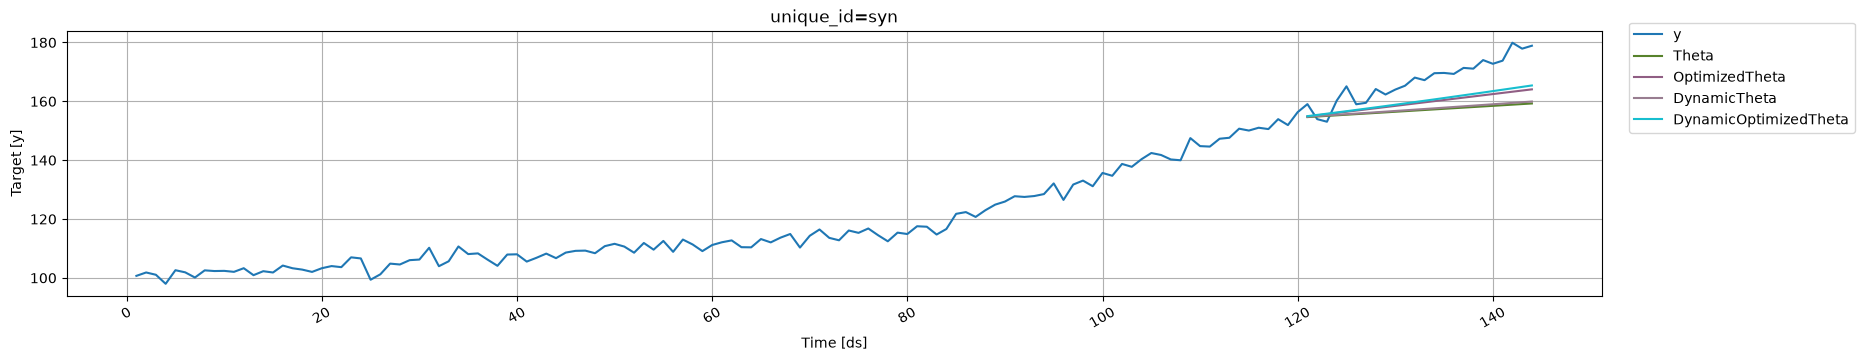

In [15]:
plot_series(syn, fc_syn)

Все модели недооценивают новый наклон — это общее ограничение Theta: тренд — одна прямая
по всей истории. OTM и DOTM выбирают θ в сотни раз больше 2 и ошибаются меньше.

## 5. DynamicTheta (DSTM) и DynamicOptimizedTheta (DOTM)

В статических моделях $A_n, B_n$ — МНК-прямая по **всем** $n$ точкам. Значит, прогноз на шаг
вперёд в момент $t < n$ (по нему считается ошибка при обучении) использует будущие наблюдения.

В динамических моделях $A_t, B_t$ пересчитываются рекурсивно — МНК только по $y_1, \dots, y_t$
(старт: $A = y_1$, $B = 0$). На горизонте прогноза пересчёт продолжается по собственным прогнозам.
DSTM: θ = 2; DOTM: θ обучается.

Траектория $B_t$ лежит в `model_["states"]` (столбцы: уровень SES, среднее, $A_t$, $B_t$, прогноз).

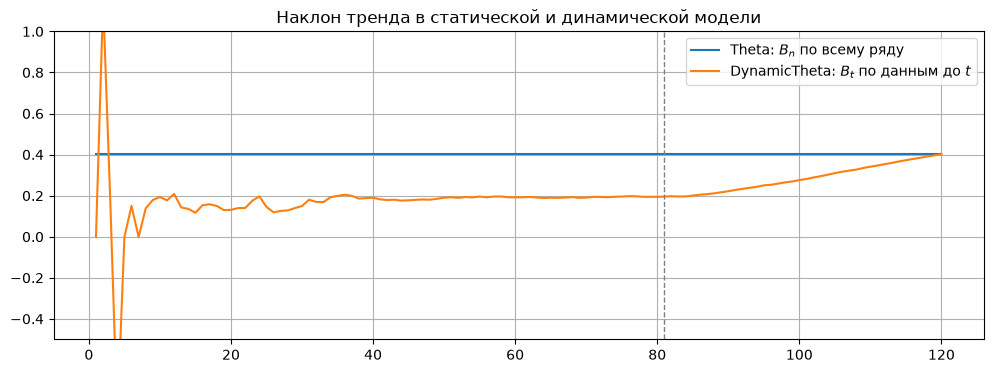

In [16]:
B_static = fitted_model(sf_syn, 0, 0)["states"][:, 3]
B_dyn = fitted_model(sf_syn, 0, 2)["states"][:, 3]

fig, ax = plt.subplots()
ax.plot(syn_train["ds"], B_static, label="Theta: $B_n$ по всему ряду")
ax.plot(syn_train["ds"], B_dyn, label="DynamicTheta: $B_t$ по данным до $t$")
ax.axvline(81, color="gray", ls="--", lw=1)
ax.set_ylim(-0.5, 1)
ax.legend()
ax.set_title("Наклон тренда в статической и динамической модели");

В последней точке рекурсивный МНК совпадает с МНК по всему ряду, поэтому $B_n$ у обеих
моделей одинаковый, и точечные прогнозы близки (таблица выше: 10.3 против 10.0).
Разница — в обучении: динамическая модель честно не видит будущего внутри истории,
поэтому $\alpha$, $\ell_0$, θ оцениваются иначе. Это настоящая модель пространства состояний:
правдоподобие и интервалы корректны.

## 6. AutoTheta

Обучает STM, OTM, DSTM, DOTM и берёт модель с минимальной ошибкой на обучении
(`mse` — та же функция потерь, что минимизируется). При `distribution` ≠ `"normal"`
выбор идёт по AIC. Параметр `model` фиксирует одну модель — так и устроены остальные классы.

Посмотрим на 50 рядах M4, что выбирает AutoTheta и какой θ получает OTM.

In [17]:
sf_m4 = StatsForecast(models=[AutoTheta(season_length=12), OptimizedTheta(season_length=12)], freq=1).fit(m4)
ids = sf_m4.uids
auto_info = pd.DataFrame(
    {
        "модель": [fitted_model(sf_m4, i, 0)["modeltype"] for i in range(len(ids))],
        "десезонализирован": [fitted_model(sf_m4, i, 0).get("decompose", False) for i in range(len(ids))],
        "θ OTM": [fitted_model(sf_m4, i, 1)["par"]["theta"] for i in range(len(ids))],
        "α OTM": [fitted_model(sf_m4, i, 1)["par"]["alpha"] for i in range(len(ids))],
    },
    index=ids,
)
auto_info["модель"].value_counts()

модель
OTM     35
DOTM     9
STM      6
Name: count, dtype: int64

In [18]:
auto_info["десезонализирован"].value_counts()

десезонализирован
True     43
False     7
Name: count, dtype: int64

In [19]:
auto_info[["θ OTM", "α OTM"]].describe().loc[["min", "25%", "50%", "75%", "max"]]

,θ OTM,α OTM
min,1.000,0.100
25%,1.003,0.570
50%,11.085,0.859
75%,1706.743,0.990
max,215161.450,0.990


- AutoTheta чаще всего выбирает OTM: у неё больше свободы, и ошибка на обучении меньше.
  Ниже увидим, что вне выборки OTM не лучшая — выбор по ошибке на обучении переобучается.
- θ у OTM почти всегда на краю: у четверти рядов θ ≈ 1 (SES без тренда), у четверти — тысячи
  и больше (SES с полным дрейфом $B_n$). Промежуточные значения, как θ = 2, — редкость.
  $\alpha$ у четверти рядов упирается в верхнюю границу 0.99.

## 7. Сравнение на M4 Monthly

Кросс-валидация: горизонт 18 месяцев (как в M4), 3 окна с шагом 18.
Метрики: sMAPE (основная в M4) и MASE с сезонностью 12. Время — на всю кросс-валидацию.

AutoARIMA на 50 рядах считается несколько минут; флаг `RUN_AUTOARIMA` позволяет её пропустить.

In [21]:
RUN_AUTOARIMA = False
H, N_WINDOWS = 18, 3

cmp_models = [
    Theta(season_length=12),
    OptimizedTheta(season_length=12),
    DynamicTheta(season_length=12),
    DynamicOptimizedTheta(season_length=12),
    AutoTheta(season_length=12),
    AutoETS(season_length=12),
    SeasonalNaive(season_length=12),
] + ([AutoARIMA(season_length=12)] if RUN_AUTOARIMA else [])

cvs, times = [], {}
for model in cmp_models:
    start = time.time()
    cv = StatsForecast(models=[model], freq=1).cross_validation(df=m4, h=H, step_size=H, n_windows=N_WINDOWS)
    times[model.alias] = time.time() - start
    cvs.append(cv.set_index(["unique_id", "ds", "cutoff", "y"]))
cv = pd.concat(cvs, axis=1).reset_index()
names = list(times)

Для MASE нужен train: берём историю до первого окна каждого ряда.

In [22]:
first_cutoff = cv.groupby("unique_id")["cutoff"].min()
train_m4 = m4[m4["ds"] <= m4["unique_id"].map(first_cutoff)]

ev = evaluate(cv.drop(columns="cutoff"), metrics=[smape, partial(mase, seasonality=12)], train_df=train_m4)
scores = ev.drop(columns="unique_id").groupby("metric").mean().T
scores["smape"] *= 100
scores = scores.rename(columns={"smape": "sMAPE, %", "mase": "MASE"})
scores["время, с"] = pd.Series(times).map("{:.1f}".format)
scores.sort_values("sMAPE, %")

metric,MASE,"sMAPE, %","время, с"
DynamicOptimizedTheta,1.186,5.345,0.6
AutoETS,1.191,5.373,10.2
DynamicTheta,1.184,5.483,0.3
Theta,1.186,5.485,0.3
AutoTheta,1.186,5.612,1.8
OptimizedTheta,1.188,5.618,0.7
SeasonalNaive,1.635,7.095,0.0


Средние близки, поэтому посмотрим ещё, на какой доле рядов каждая модель лучшая по sMAPE.

In [23]:
per_series = ev[ev["metric"] == "smape"].set_index("unique_id")[names]
per_series.idxmin(axis=1).value_counts(normalize=True).rename("доля рядов").round(2)

AutoETS                  0.40
OptimizedTheta           0.24
DynamicOptimizedTheta    0.18
SeasonalNaive            0.08
Theta                    0.06
AutoTheta                0.02
DynamicTheta             0.02
Name: доля рядов, dtype: float64

Прогнозы последнего окна на трёх рядах.

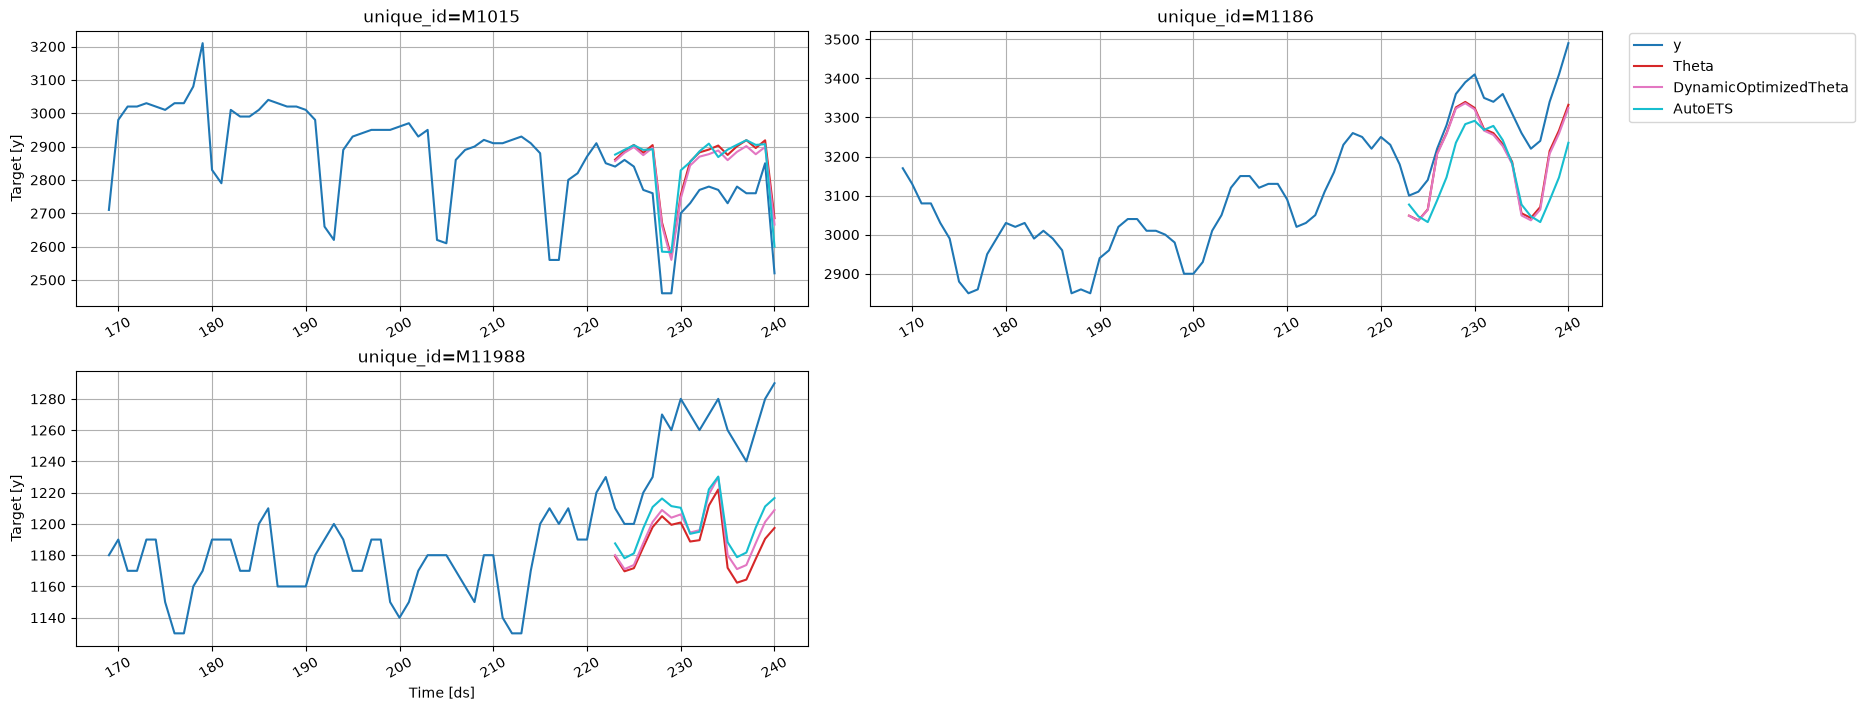

In [24]:
last = cv[cv["cutoff"] == cv["unique_id"].map(cv.groupby("unique_id")["cutoff"].max())]
show_ids = ids[:3]
show_models = ["Theta", "DynamicOptimizedTheta", "AutoETS"] + (["AutoARIMA"] if RUN_AUTOARIMA else [])
plot_series(
    m4.groupby("unique_id").tail(72),
    last.drop(columns=["cutoff", "y"]),
    ids=list(show_ids),
    models=show_models,
)

**Выводы.**
- Theta-модели на уровне AutoETS (DOTM даже чуть лучше по sMAPE) и считаются в 10–30 раз быстрее.
  По MASE модели семейства и AutoETS неразличимы. SeasonalNaive заметно хуже.
- Простая `Theta` почти не уступает: сильный и быстрый бейзлайн.
- OTM в среднем худшая из Theta, но лучшая на четверти рядов: θ на краю
  (SES или полный дрейф) то сильно выигрывает, то сильно проигрывает.
- AutoTheta выбирает по ошибке на обучении, чаще всего OTM, и наследует её разброс:
  в среднем хуже фиксированной `Theta`.
- AutoETS в среднем на уровне DOTM, но чаще всех лучшая на отдельном ряде (40%):
  у неё больше форм тренда и сезонности.
- AutoARIMA на прототипе (200 таких же рядов) была хуже Theta по sMAPE и считалась
  дольше всех (~9 мин против секунд у Theta).
- На 50 рядах и 3 окнах разница в доли процента sMAPE ненадёжна.

## 8. Итоги

| Модель | θ | Тренд | Обучается | Когда брать |
|---|---|---|---|---|
| `Theta` | 2 | МНК по всему ряду | $\ell_0, \alpha$ | бейзлайн по умолчанию |
| `OptimizedTheta` | обучается, ≥ 1 | МНК по всему ряду | $\ell_0, \alpha, \theta$ | сильный или меняющийся тренд; риск переобучения |
| `DynamicTheta` | 2 | рекурсивный МНК | $\ell_0, \alpha$ | нужна честная модель пространства состояний |
| `DynamicOptimizedTheta` | обучается, ≥ 1 | рекурсивный МНК | $\ell_0, \alpha, \theta$ | то же + свобода по θ |
| `AutoTheta` | — | — | выбор из четырёх по MSE на обучении | когда нет времени выбирать |

**Ограничения семейства:**
- одна сезонность и классическая декомпозиция с повтором последнего цикла —
  для PJME (24 и 168 часов) лучше MSTL из ноутбука 02;
- тренд линейный и общий для всей истории: изломы Theta ловит плохо;
- θ < 1 в statsforecast недоступен.